In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')
print('All libraries imported!')

All libraries imported!


In [3]:
df = pd.read_csv('store_customers.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (1000, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
5,1005,M,33.0,36.7,73.0
6,1006,F,48.0,90.4,34.0
7,1007,F,41.0,74.8,35.0
8,1008,F,31.0,42.3,43.0
9,1009,M,39.0,48.6,61.0


In [4]:
print(df.isnull().sum())
print('Duplicates:', df.duplicated().sum())
df = df.drop_duplicates()
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].median(), inplace=True)
df['Spending Score (1-100)'].fillna(df['Spending Score (1-100)'].median(), inplace=True)
print(df.dtypes)
df.describe()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64
Duplicates: 0
CustomerID                  int64
Gender                     object
Age                       float64
Annual Income (k$)        float64
Spending Score (1-100)    float64
dtype: object


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,1499.500000,38.918000,57.116500,42.672000
std,288.819436,13.361505,28.575769,20.043956
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,35.075000,31.750000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.325000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


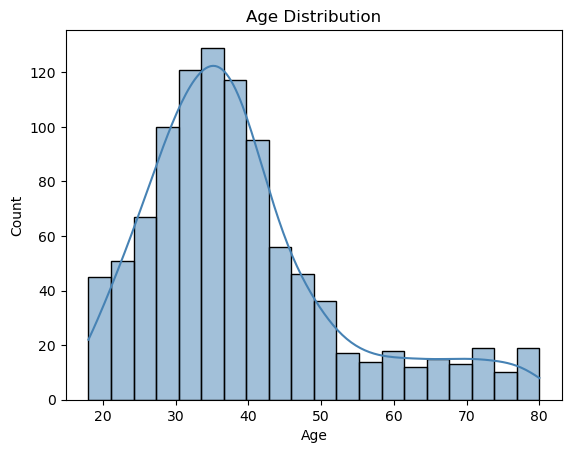

In [5]:
sns.histplot(df['Age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution')
plt.show()

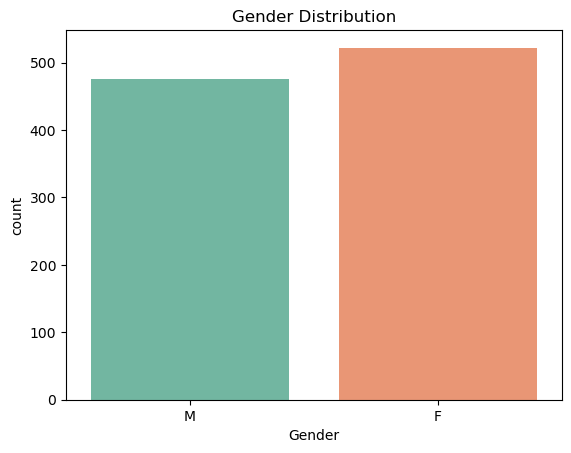

In [6]:
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.show()

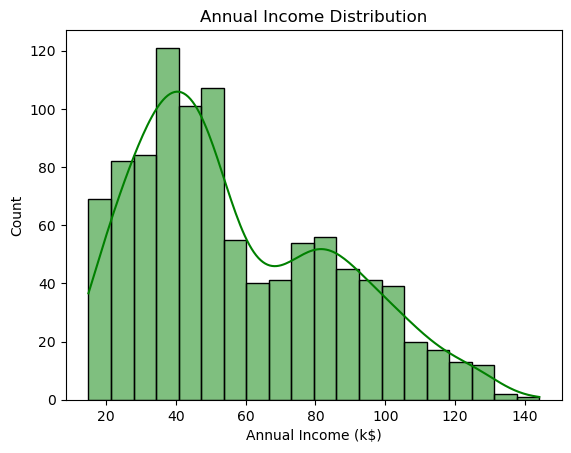

In [7]:
sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, color='green')
plt.title('Annual Income Distribution')
plt.show()

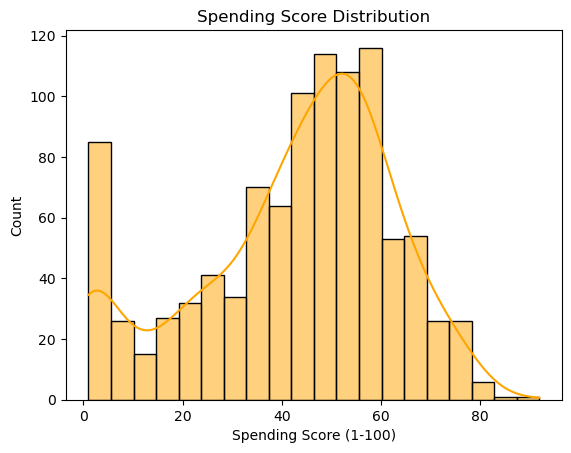

In [8]:
sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, color='orange')
plt.title('Spending Score Distribution')
plt.show()

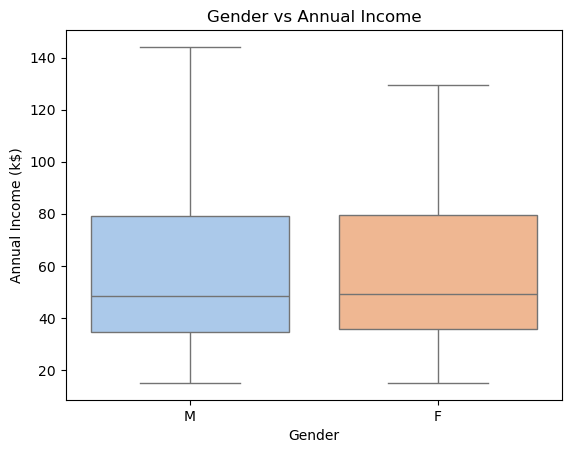

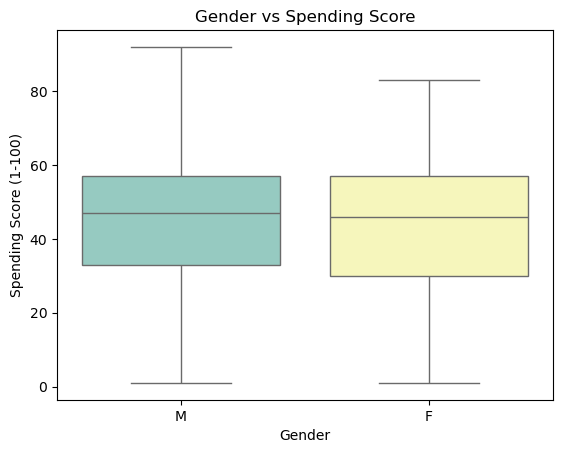

In [9]:
sns.boxplot(x='Gender', y='Annual Income (k$)', data=df, palette='pastel')
plt.title('Gender vs Annual Income')
plt.show()

sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df, palette='Set3')
plt.title('Gender vs Spending Score')
plt.show()

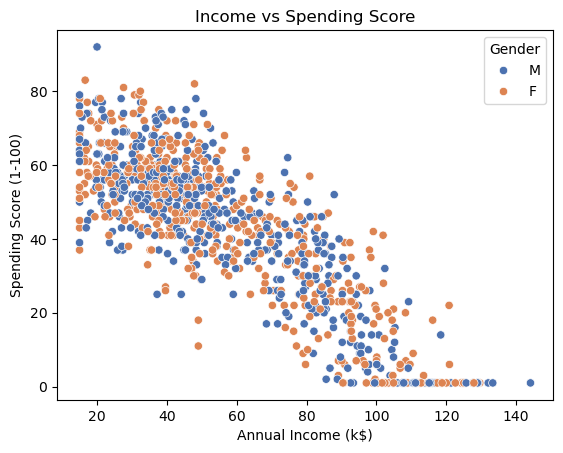

In [10]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Gender', data=df, palette='deep')
plt.title('Income vs Spending Score')
plt.show()

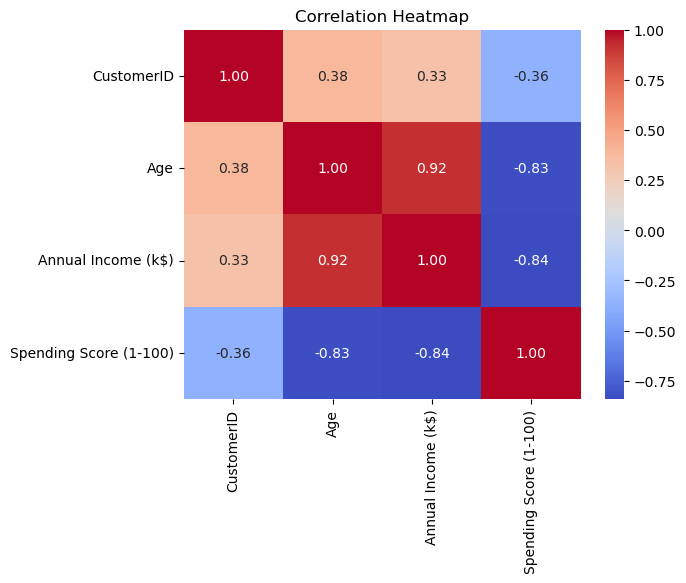

In [11]:
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

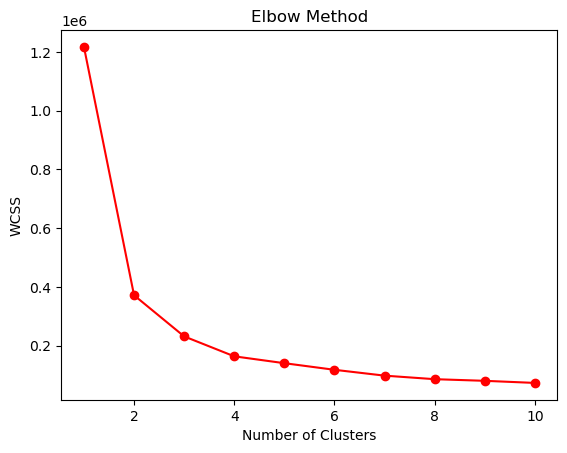

In [13]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='red')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

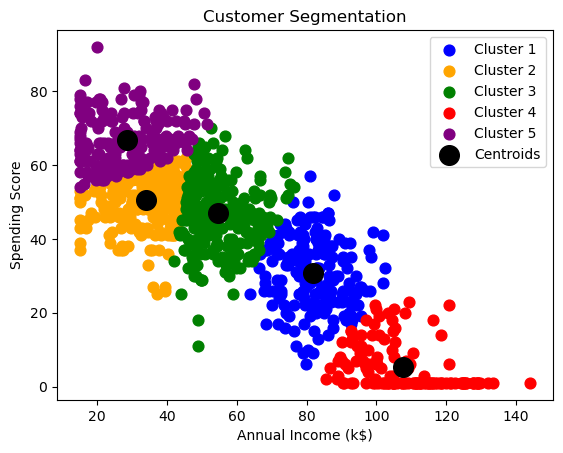

In [14]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)
df['Cluster'] = y_kmeans

colors = ['blue', 'orange', 'green', 'red', 'purple']
for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=60, label=f'Cluster {i+1}', color=colors[i])

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')
plt.title('Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

In [15]:
summary = df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean().round(2)
print(summary)

labels = {
    0: 'High Income, High Spenders (VIP)',
    1: 'Low Income, High Spenders (Impulsive)',
    2: 'Medium Income, Medium Spenders (Standard)',
    3: 'High Income, Low Spenders (Careful)',
    4: 'Low Income, Low Spenders (Budget)'
}
for k, v in labels.items():
    print(f'Cluster {k}: {v}')

           Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                   
0        45.45               81.93                   30.65
1        29.81               33.91                   50.53
2        36.78               54.51                   46.90
3        65.51              107.59                    5.40
4        27.59               28.53                   66.93
Cluster 0: High Income, High Spenders (VIP)
Cluster 1: Low Income, High Spenders (Impulsive)
Cluster 2: Medium Income, Medium Spenders (Standard)
Cluster 3: High Income, Low Spenders (Careful)
Cluster 4: Low Income, Low Spenders (Budget)


Customer_Type
Low Value     917
High Value     83
Name: count, dtype: int64


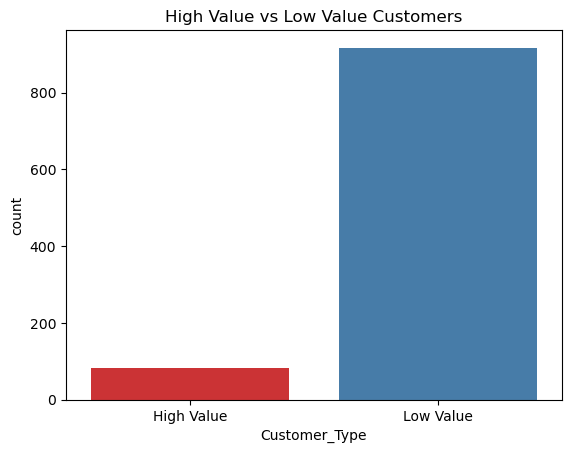

In [16]:
df['Customer_Type'] = np.where(
    (df['Annual Income (k$)'] > df['Annual Income (k$)'].median()) &
    (df['Spending Score (1-100)'] > df['Spending Score (1-100)'].median()),
    'High Value', 'Low Value'
)
print(df['Customer_Type'].value_counts())

sns.countplot(x='Customer_Type', data=df, palette='Set1')
plt.title('High Value vs Low Value Customers')
plt.show()

In [17]:
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
df['Target'] = (df['Customer_Type'] == 'High Value').astype(int)

features = ['Gender_Encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_model = df[features]
y_model = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42)

# Logistic Regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
lr = LogisticRegression()
lr.fit(X_train_s, y_train)
print('Logistic Regression Accuracy:', round(accuracy_score(y_test, lr.predict(X_test_s))*100, 2), '%')

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Random Forest Accuracy:', round(accuracy_score(y_test, y_pred)*100, 2), '%')
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 93.0 %
Random Forest Accuracy: 100.0 %
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       187
           1       1.00      1.00      1.00        13

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



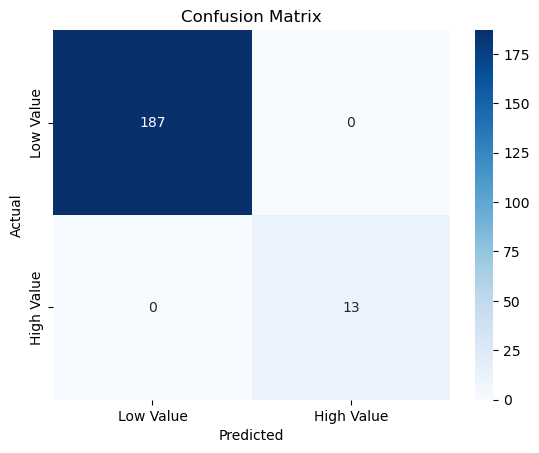

In [18]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Value','High Value'],
            yticklabels=['Low Value','High Value'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

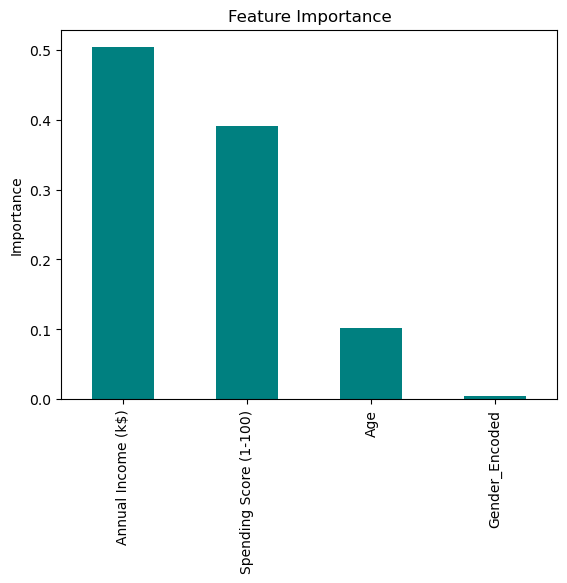

In [19]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar', color='teal')
plt.title('Feature Importance')
plt.ylabel('Importance')
plt.show()

In [20]:
print("""
================================================
        BUSINESS INSIGHT REPORT
================================================
1. Most customers are aged 25-45
2. Female customers slightly outnumber males
3. 5 Segments identified:
   - VIP: High income + High spending
   - Impulsive: Low income + High spending
   - Standard: Medium income + Medium spending
   - Careful: High income + Low spending
   - Budget: Low income + Low spending
4. Spending Score is the #1 predictor of value
5. RECOMMENDATIONS:
   - Retain VIP customers with loyalty rewards
   - Target Careful customers with premium ads
   - Offer discounts to Budget segment
================================================
""")


        BUSINESS INSIGHT REPORT
1. Most customers are aged 25-45
2. Female customers slightly outnumber males
3. 5 Segments identified:
   - VIP: High income + High spending
   - Impulsive: Low income + High spending
   - Standard: Medium income + Medium spending
   - Careful: High income + Low spending
   - Budget: Low income + Low spending
4. Spending Score is the #1 predictor of value
5. RECOMMENDATIONS:
   - Retain VIP customers with loyalty rewards
   - Target Careful customers with premium ads
   - Offer discounts to Budget segment



In [ ]:
df.to_csv("output.csv", index=False)

In [ ]:
import os
print(os.getcwd())